In [1]:
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [19]:
ruta_archivo = '../datasets/raw/s1/S1_E2_A1.mat' # Ejemplo: Sujeto 1, Ejercicio 1
mat_data = scipy.io.loadmat(ruta_archivo)

In [20]:
print("--- VARIABLES ORIGINALES DEL ARCHIVO ---")
print(mat_data.keys())

--- VARIABLES ORIGINALES DEL ARCHIVO ---
dict_keys(['__header__', '__version__', '__globals__', 'emg', 'acc', 'stimulus', 'glove', 'subject', 'exercise', 'repetition', 'restimulus', 'rerepetition', 'age', 'circumference', 'frequency', 'gender', 'height', 'weight', 'laterality', 'sensor'])


In [21]:
emg_completo = mat_data['emg']

gestos = mat_data['restimulus'] 

repeticiones = mat_data['repetition']

print(f"\nTamaño original EMG: {emg_completo.shape} -> (Muestras de tiempo, 16 sensores)")


Tamaño original EMG: (179901, 16) -> (Muestras de tiempo, 16 sensores)


In [22]:
emg_8_canales = mat_data['emg'][:, 0:8]
print(f"Tamaño para mi Tesis: {emg_8_canales.shape} -> ¡Solo 8 canales!")

Tamaño para mi Tesis: (179901, 8) -> ¡Solo 8 canales!


In [23]:
print(emg_8_canales)

[[-20.   7. -11. ...   1.  -1.   3.]
 [ -8. -20. -27. ...   6.   5.  -3.]
 [  8.  18.  30. ...  37. -45. -12.]
 ...
 [ -3.  -2.  -2. ...   0.  -1.  -5.]
 [ -4.  -2.  -1. ...   0.  -1.   0.]
 [ -7.  -1.   2. ...   0.   1.  -2.]]


In [27]:
print(mat_data['frequency'])

[[200]]


In [ ]:
columnas_sensores = [f'ch{i+1}' for i in range(8)]
df = pd.DataFrame(emg_8_canales, columns=columnas_sensores)
df['gesto_id'] = gestos # Agregamos la etiqueta al final

print("\n--- PRIMERAS 5 FILAS DE TUS DATOS ---")
print(df.head())


--- PRIMERAS 5 FILAS DE TUS DATOS ---
    ch1   ch2   ch3  ch4   ch5   ch6   ch7  ch8  gesto_id
0 -22.0  -2.0 -16.0 -7.0  -3.0  -1.0  -2.0 -4.0         0
1   5.0  -4.0 -12.0 -3.0   8.0  25.0   1.0  1.0         0
2  -6.0   1.0   4.0 -1.0  -9.0   0.0 -10.0 -3.0         0
3  15.0  10.0  19.0  9.0  10.0   7.0   2.0  1.0         0
4  -1.0 -16.0 -17.0  0.0  -2.0  -7.0   2.0  0.0         0


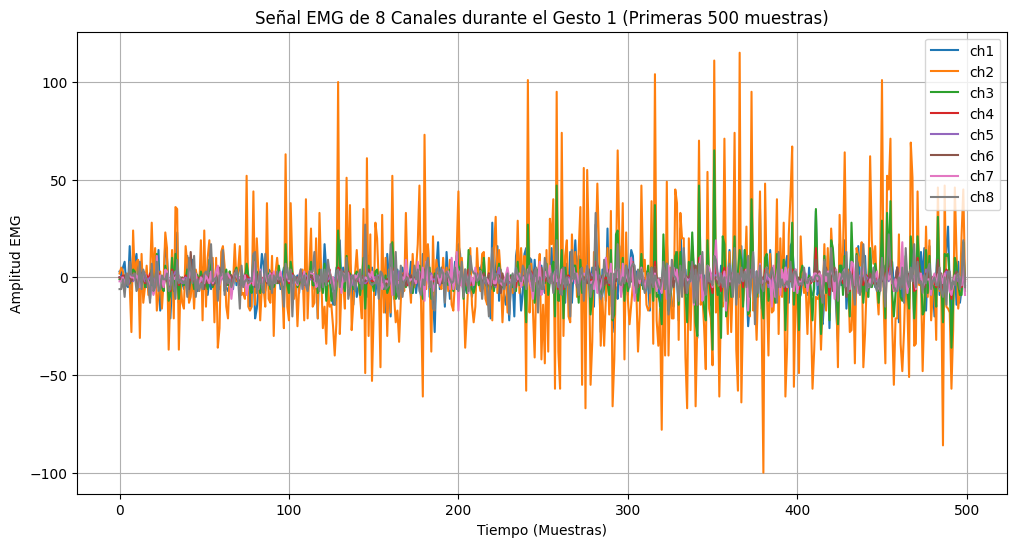

In [11]:
indice_gesto_1 = np.where(gestos == 1)[0]

if len(indice_gesto_1) > 0:
    plt.figure(figsize=(12, 6))
    # Graficamos los 8 canales solo durante ese gesto
    plt.plot(emg_mi_tesis[indice_gesto_1[0]:indice_gesto_1[0]+500, :])
    plt.title('Señal EMG de 8 Canales durante el Gesto 1 (Primeras 500 muestras)')
    plt.xlabel('Tiempo (Muestras)')
    plt.ylabel('Amplitud EMG')
    plt.legend(columnas_sensores, loc='upper right')
    plt.grid(True)
    plt.show()

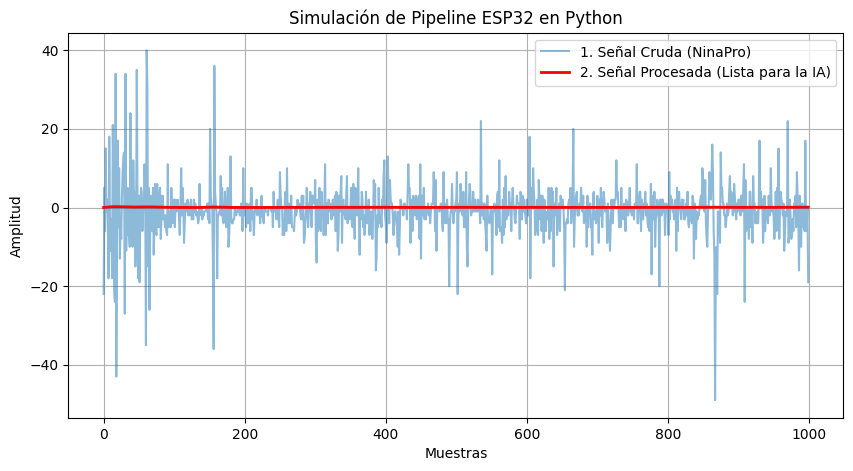

In [ ]:
import numpy as np
from scipy.signal import iirnotch, butter, filtfilt
import matplotlib.pyplot as plt

# Frecuencia de muestreo de NinaPro DB5
FS = 200.0  

def aplicar_pipeline_emg(senal_cruda, fs):
    """
    Simula el procesamiento DSP que ocurrirá en el ESP32.
    """
    
    # 1. FILTRO NOTCH (Eliminar ruido de red eléctrica a 50Hz)
    f0 = 50.0  # Frecuencia a eliminar (50Hz en Chile)
    Q = 30.0   # Factor de calidad (qué tan "fino" es el corte)
    b_notch, a_notch = iirnotch(f0, Q, fs)
    senal_notch = filtfilt(b_notch, a_notch, senal_cruda)

    # 2. FILTRO PASA-BANDA (20Hz a 90Hz) - Limitado por Nyquist de NinaPro
    lowcut = 20.0
    highcut = 90.0
    b_band, a_band = butter(N=4, Wn=[lowcut, highcut], fs=fs, btype='bandpass')
    senal_band = filtfilt(b_band, a_band, senal_notch)

    # 3. RECTIFICACIÓN (Valor Absoluto)
    senal_rectificada = np.abs(senal_band)

    # 4. SUAVIZADO / ENVOLVENTE (Filtro Pasa-Bajo a 5Hz)
    fc_low = 5.0 # Frecuencia de corte para la envolvente
    b_low, a_low = butter(N=4, Wn=fc_low, fs=fs, btype='lowpass')
    senal_suave = filtfilt(b_low, a_low, senal_rectificada)

    # 5. NORMALIZACIÓN (Min-Max Scaling 0 a 1)
    # Se suma un pequeño epsilon (1e-6) para evitar división por cero
    senal_final = (senal_suave - np.min(senal_suave)) / (np.max(senal_suave) - np.min(senal_suave) + 1e-6)

    return senal_final

# --- PRUEBA DEL PIPELINE ---
# (Asumiendo que 'emg_mi_tesis' tiene tus 8 canales del script anterior)

# Aplicar el filtro a UN solo canal para probar (ej. Canal 1)
canal_1_crudo = emg_mi_tesis[:, 0]
canal_1_procesado = aplicar_pipeline_emg(canal_1_crudo, FS)

# Graficar el Antes y Después
plt.figure(figsize=(10, 5))
# plt.plot(canal_1_crudo[:1000], label='1. Señal Cruda (NinaPro)', alpha=0.5)
plt.plot(canal_1_procesado[:1000], label='2. Señal Procesada (Lista para la IA)', linewidth=2, color='red')
plt.title('Simulación de Pipeline ESP32 en Python')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()